# Inventory Optimization & Reorder Point Prediction System

---

**System Overview:**
This notebook implements an end-to-end inventory optimization pipeline including:
-  Advanced EDA with trend & seasonality decomposition
-  Demand forecasting (Prophet + LSTM ensemble)
-  Reorder Point & Safety Stock computation
-  Actionable business recommendations




##  Step 1 — Install & Import Libraries

In [ ]:
#  Install dependencies
!pip install prophet scikit-learn tensorflow matplotlib seaborn statsmodels --quiet

#  Standard libraries 
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime, timedelta

#  Statistical & ML 
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

#  Prophet 
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

#  Plot styling
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2d3748',
    'axes.labelcolor':  '#e2e8f0',
    'xtick.color':      '#a0aec0',
    'ytick.color':      '#a0aec0',
    'text.color':       '#e2e8f0',
    'grid.color':       '#2d3748',
    'grid.alpha':       0.5,
    'font.family':      'monospace',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
PALETTE = ['#00d4ff', '#ff6b6b', '#ffd93d', '#6bcb77', '#c77dff', '#ff9f43']

print(' All libraries loaded successfully')
print(f'   TensorFlow  : {tf.__version__}')
print(f'   NumPy       : {np.__version__}')
print(f'   Pandas      : {pd.__version__}')


✅ All libraries loaded successfully
   TensorFlow  : 2.19.0
   NumPy       : 2.0.2
   Pandas      : 2.2.2


##  Step 2 — Load & Preprocess Dataset

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Option A: Upload your own CSV  →  uncomment lines below
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(next(iter(uploaded)))
#
# Option B: Synthetic multi-SKU dataset (default)
# ─────────────────────────────────────────────────────────────────────────────

np.random.seed(42)

def generate_inventory_data(n_days: int = 730, n_skus: int = 5) -> pd.DataFrame:
    """Generate realistic synthetic inventory data with trend, seasonality & noise."""
    records = []
    start   = datetime(2022, 1, 1)
    skus    = [f'SKU-{chr(65+i)}' for i in range(n_skus)]

    sku_params = {
        'SKU-A': dict(base=120, trend=0.06, amp=30,  noise=12, lead=7,  cost=25.0),
        'SKU-B': dict(base=80,  trend=0.03, amp=20,  noise=8,  lead=5,  cost=45.0),
        'SKU-C': dict(base=200, trend=0.08, amp=60,  noise=20, lead=10, cost=15.0),
        'SKU-D': dict(base=50,  trend=0.01, amp=10,  noise=5,  lead=3,  cost=80.0),
        'SKU-E': dict(base=300, trend=0.10, amp=80,  noise=30, lead=14, cost=8.0),
    }

    for sku in skus:
        p = sku_params[sku]
        for d in range(n_days):
            date   = start + timedelta(days=d)
            trend  = p['base'] + p['trend'] * d
            weekly = p['amp'] * np.sin(2 * np.pi * d / 7)       # weekly seasonality
            annual = p['amp'] * 0.5 * np.sin(2 * np.pi * d / 365)  # annual seasonality
            promo  = 1.4 if (d % 90 < 7) else 1.0               # promo spike every quarter
            demand = max(0, (trend + weekly + annual) * promo + np.random.normal(0, p['noise']))
            records.append({
                'date':       date,
                'sku':        sku,
                'demand':     round(demand),
                'stock_level': round(demand * np.random.uniform(1.5, 3.0)),
                'lead_time_days': p['lead'] + np.random.randint(-1, 2),
                'unit_cost':  p['cost'],
                'holding_cost_pct': 0.25,
                'order_cost': 150.0,
            })

    return pd.DataFrame(records)


df_raw = generate_inventory_data()
df_raw['date'] = pd.to_datetime(df_raw['date'])

# ── Preprocessing ─────────────────────────────────────────────────────────────
df = df_raw.copy()
df['day_of_week']  = df['date'].dt.dayofweek
df['month']        = df['date'].dt.month
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter']      = df['date'].dt.quarter
df['is_weekend']   = df['day_of_week'].isin([5, 6]).astype(int)
df['demand_7d_ma'] = df.groupby('sku')['demand'].transform(lambda x: x.rolling(7, min_periods=1).mean())
df['demand_30d_ma']= df.groupby('sku')['demand'].transform(lambda x: x.rolling(30, min_periods=1).mean())
df['demand_std_7d']= df.groupby('sku')['demand'].transform(lambda x: x.rolling(7, min_periods=1).std().fillna(0))

print(f'✅ Dataset ready: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   SKUs          : {", ".join(df["sku"].unique())}')
print(f'   Date range    : {df["date"].min().date()} → {df["date"].max().date()}')
df.head()


✅ Dataset ready: 3,650 rows × 16 columns
   SKUs          : SKU-A, SKU-B, SKU-C, SKU-D, SKU-E
   Date range    : 2022-01-01 → 2023-12-31


,date,sku,demand,stock_level,lead_time_days,unit_cost,holding_cost_pct,order_cost,day_of_week,month,week_of_year,quarter,is_weekend,demand_7d_ma,demand_30d_ma,demand_std_7d
0,2022-01-01,SKU-A,174,452,6,25.0,0.25,150.0,5,1,52,1,1,174.000000,174.000000,0.000000
1,2022-01-02,SKU-A,200,478,7,25.0,0.25,150.0,6,1,52,1,1,187.000000,187.000000,18.384776
2,2022-01-03,SKU-A,213,546,7,25.0,0.25,150.0,0,1,1,1,0,195.666667,195.666667,19.857828
3,2022-01-04,SKU-A,200,316,7,25.0,0.25,150.0,1,1,1,1,0,196.750000,196.750000,16.357975
4,2022-01-05,SKU-A,145,257,7,25.0,0.25,150.0,2,1,1,1,0,186.400000,186.400000,27.134848


## 🔍 Step 3 — Exploratory Data Analysis (EDA)

In [3]:
# ── Summary statistics ────────────────────────────────────────────────────────
summary = df.groupby('sku')['demand'].agg(['mean','std','min','max','sum'])
summary.columns = ['Avg Daily Demand', 'Std Dev', 'Min', 'Max', 'Total Demand']
summary['CV (%)'] = (summary['Std Dev'] / summary['Avg Daily Demand'] * 100).round(1)
print('\n📊 Demand Summary by SKU:')
print(summary.round(1).to_string())



📊 Demand Summary by SKU:
       Avg Daily Demand  Std Dev  Min  Max  Total Demand  CV (%)
sku                                                             
SKU-A             147.1     33.1   78  288        107367    22.5
SKU-B              94.0     21.3   38  186         68645    22.6
SKU-C             236.6     59.1   92  458        172706    25.0
SKU-D              55.6     11.3   29  104         40556    20.4
SKU-E             350.4     80.2  180  652        255775    22.9


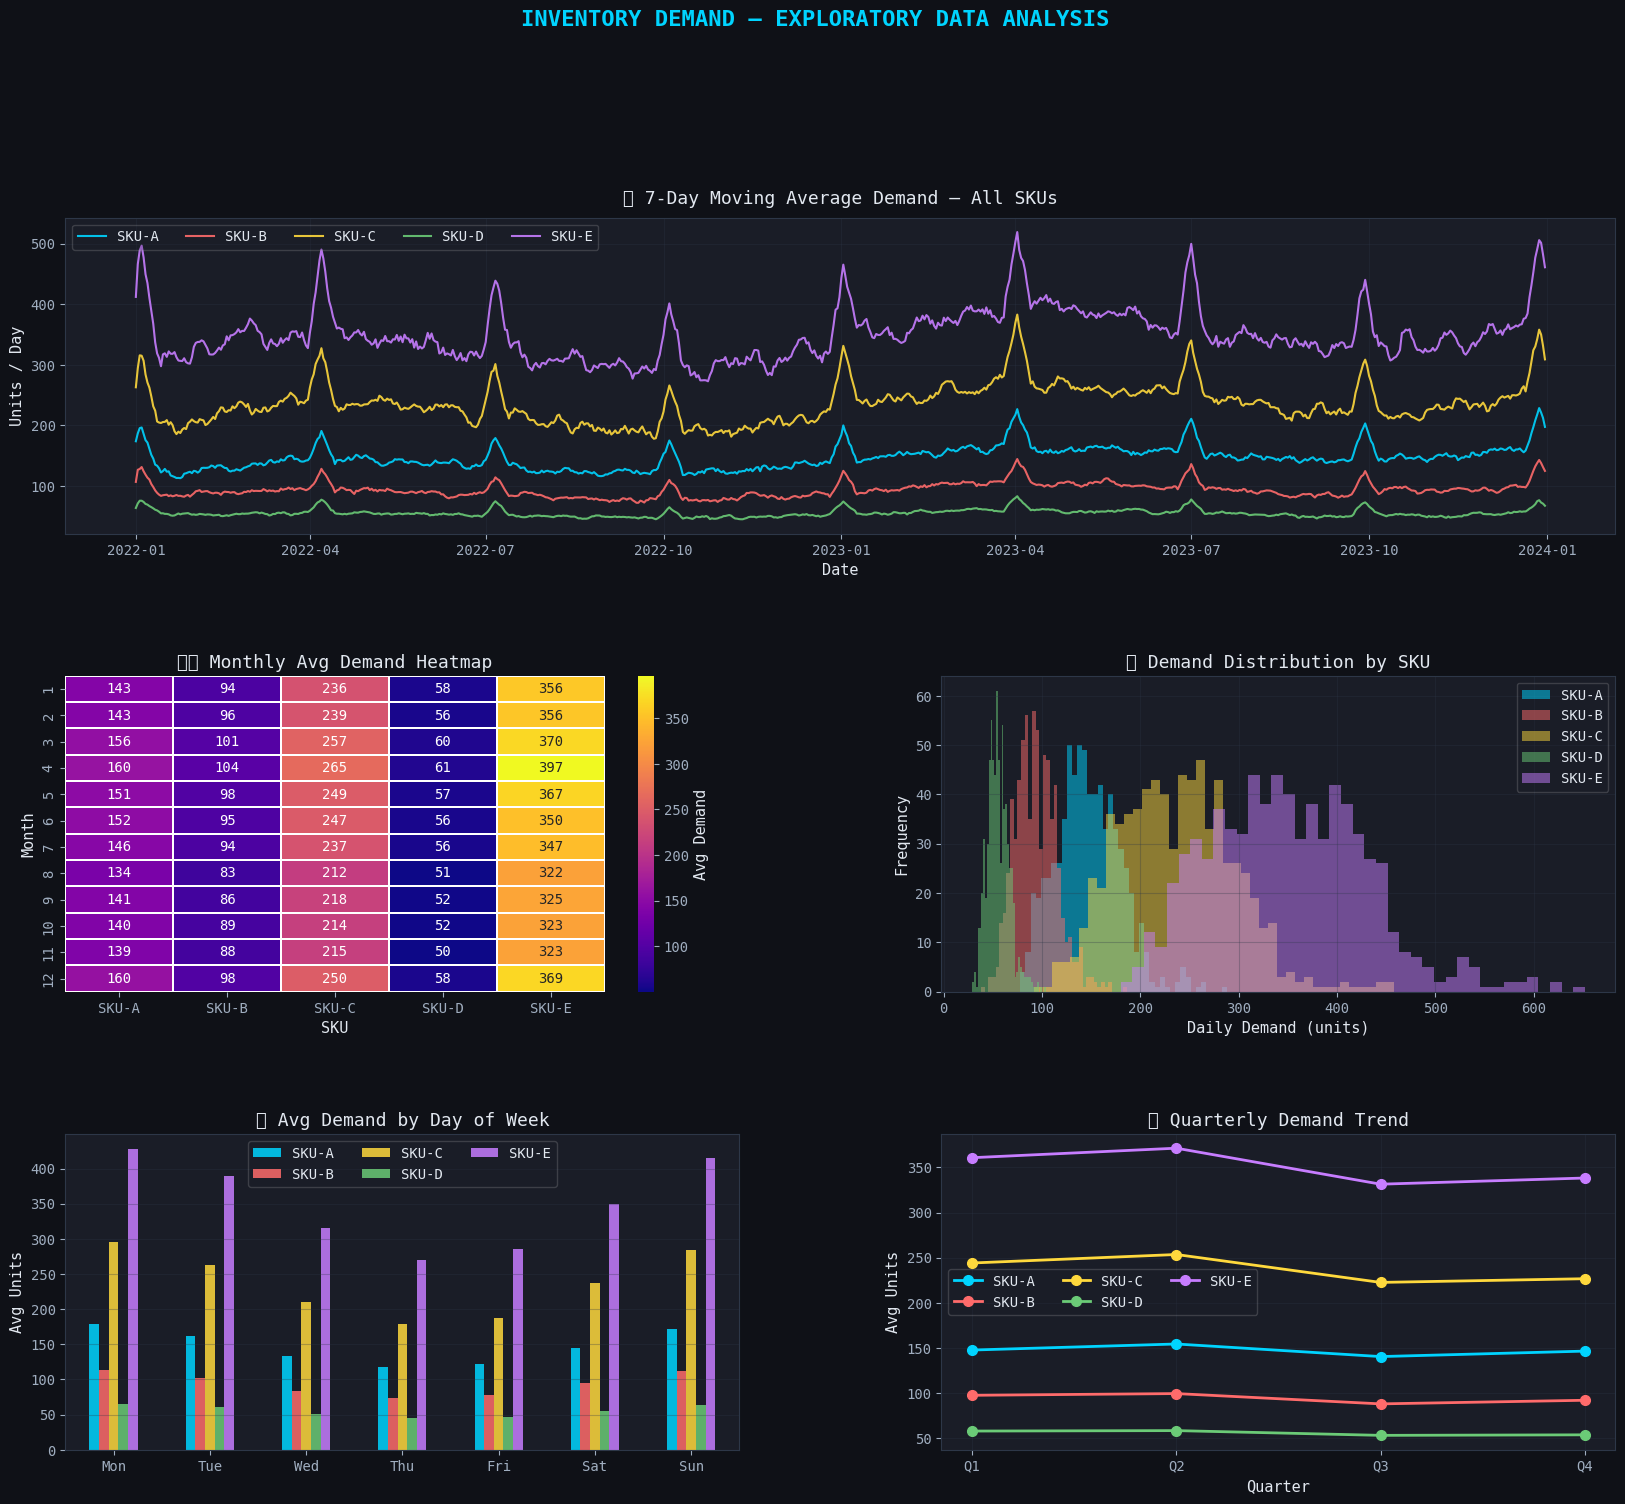

✅ EDA dashboard saved as eda_dashboard.png


In [4]:
# ── EDA Visualizations ────────────────────────────────────────────────────────
skus   = df['sku'].unique()
colors = PALETTE[:len(skus)]

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#0f1117')
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# ── Panel 1: Daily demand all SKUs ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
for sku, col in zip(skus, colors):
    sub = df[df['sku'] == sku]
    ax1.plot(sub['date'], sub['demand_7d_ma'], label=sku, color=col, lw=1.5, alpha=0.9)
ax1.set_title('📈 7-Day Moving Average Demand — All SKUs', pad=10)
ax1.set_xlabel('Date'); ax1.set_ylabel('Units / Day')
ax1.legend(ncol=5, loc='upper left', framealpha=0.2)
ax1.grid(True, alpha=0.3)

# ── Panel 2: Monthly demand heatmap ───────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
pivot = df.groupby(['month', 'sku'])['demand'].mean().unstack()
sns.heatmap(pivot, ax=ax2, cmap='plasma', linewidths=0.3,
            annot=True, fmt='.0f', cbar_kws={'label': 'Avg Demand'})
ax2.set_title('🗓️ Monthly Avg Demand Heatmap')
ax2.set_xlabel('SKU'); ax2.set_ylabel('Month')

# ── Panel 3: Demand distribution ──────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
for sku, col in zip(skus, colors):
    data = df[df['sku'] == sku]['demand']
    ax3.hist(data, bins=40, alpha=0.5, color=col, label=sku, edgecolor='none')
ax3.set_title('📊 Demand Distribution by SKU')
ax3.set_xlabel('Daily Demand (units)'); ax3.set_ylabel('Frequency')
ax3.legend(framealpha=0.2)
ax3.grid(True, alpha=0.3)

# ── Panel 4: Day-of-week pattern ──────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_data   = df.groupby(['day_of_week','sku'])['demand'].mean().unstack()
dow_data.index = dow_labels
dow_data.plot(ax=ax4, kind='bar', color=colors, edgecolor='none', alpha=0.85)
ax4.set_title('📅 Avg Demand by Day of Week')
ax4.set_xlabel(''); ax4.set_ylabel('Avg Units')
ax4.legend(ncol=3, framealpha=0.2)
ax4.grid(True, alpha=0.3, axis='y'); ax4.set_xticklabels(dow_labels, rotation=0)

# ── Panel 5: Quarterly trend ───────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
q_data = df.groupby(['quarter','sku'])['demand'].mean().unstack()
q_data.plot(ax=ax5, kind='line', marker='o', color=colors, lw=2, ms=7)
ax5.set_title('📦 Quarterly Demand Trend')
ax5.set_xlabel('Quarter'); ax5.set_ylabel('Avg Units')
ax5.set_xticks([1,2,3,4]); ax5.set_xticklabels(['Q1','Q2','Q3','Q4'])
ax5.legend(ncol=3, framealpha=0.2); ax5.grid(True, alpha=0.3)

plt.suptitle('INVENTORY DEMAND — EXPLORATORY DATA ANALYSIS',
             fontsize=16, fontweight='bold', color='#00d4ff', y=1.01)
plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ EDA dashboard saved as eda_dashboard.png')


## 🔬 Step 4 — Time Series Decomposition & Stationarity


🔬 Augmented Dickey-Fuller Test — SKU-A
   ADF Statistic : -2.5706
   p-value       : 0.0992
   Series is     : ⚠️ NON-STATIONARY (differencing may help)


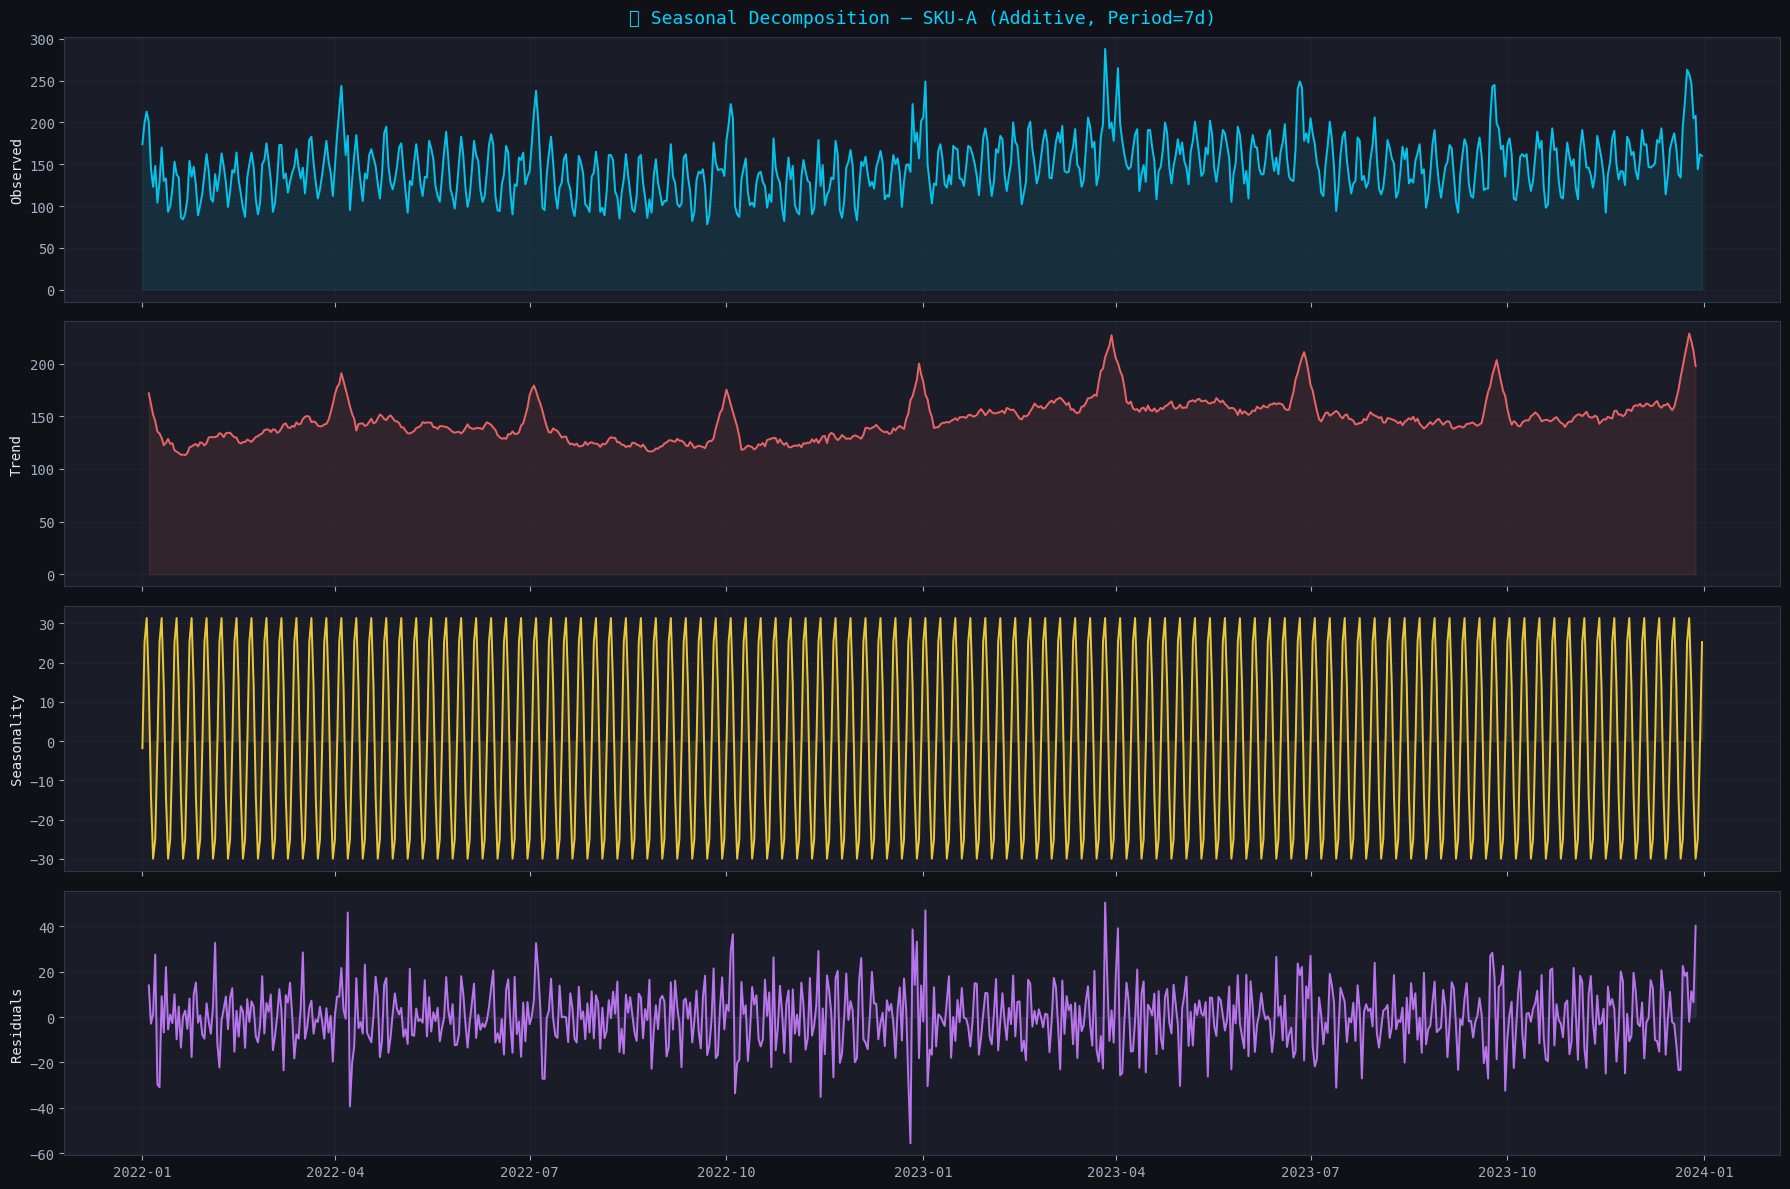

In [5]:
TARGET_SKU = 'SKU-A'   # ← change to analyse a different SKU

ts = df[df['sku'] == TARGET_SKU].set_index('date')['demand'].asfreq('D').fillna(method='ffill')

# ── ADF Stationarity test ─────────────────────────────────────────────────────
adf_result = adfuller(ts, autolag='AIC')
print(f'\n🔬 Augmented Dickey-Fuller Test — {TARGET_SKU}')
print(f'   ADF Statistic : {adf_result[0]:.4f}')
print(f'   p-value       : {adf_result[1]:.4f}')
print(f'   Series is     : {"✅ STATIONARY" if adf_result[1] < 0.05 else "⚠️ NON-STATIONARY (differencing may help)"}')

# ── Seasonal decomposition ────────────────────────────────────────────────────
decomp = seasonal_decompose(ts, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)
fig.patch.set_facecolor('#0f1117')
components = [
    (ts,              'Observed',    PALETTE[0]),
    (decomp.trend,    'Trend',       PALETTE[1]),
    (decomp.seasonal, 'Seasonality', PALETTE[2]),
    (decomp.resid,    'Residuals',   PALETTE[4]),
]
for ax, (series, label, color) in zip(axes, components):
    ax.plot(series.index, series.values, color=color, lw=1.4, alpha=0.9)
    ax.fill_between(series.index, series.values, alpha=0.1, color=color)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, alpha=0.25)
    ax.set_facecolor('#1a1d27')

axes[0].set_title(f'📉 Seasonal Decomposition — {TARGET_SKU} (Additive, Period=7d)',
                  fontsize=13, color='#00d4ff', pad=10)
plt.tight_layout()
plt.savefig('decomposition.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


## 🔮 Step 5A — Prophet Demand Forecasting

In [6]:
FORECAST_HORIZON = 30   # days to forecast
TRAIN_CUTOFF     = 0.85  # 85% train / 15% test split

results_prophet  = {}
models_prophet   = {}

for sku in df['sku'].unique():
    print(f'\n🔮 Training Prophet for {sku} ...')
    sub  = df[df['sku'] == sku][['date','demand']].rename(columns={'date':'ds','demand':'y'})
    sub  = sub.sort_values('ds').reset_index(drop=True)

    cut  = int(len(sub) * TRAIN_CUTOFF)
    train, test = sub.iloc[:cut], sub.iloc[cut:]

    # ── Build Prophet model ────────────────────────────────────────────────────
    m = Prophet(
        yearly_seasonality  = True,
        weekly_seasonality  = True,
        daily_seasonality   = False,
        seasonality_mode    = 'multiplicative',
        changepoint_prior_scale = 0.15,
        seasonality_prior_scale = 10.0,
        interval_width      = 0.95,
    )
    m.add_country_holidays(country_name='US')
    m.fit(train)

    # ── In-sample evaluation on test split ────────────────────────────────────
    forecast_test = m.predict(test[['ds']])
    y_true  = test['y'].values
    y_pred  = forecast_test['yhat'].values
    mae     = mean_absolute_error(y_true, y_pred)
    rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
    mape    = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100

    # ── Future forecast ───────────────────────────────────────────────────────
    future   = m.make_future_dataframe(periods=FORECAST_HORIZON)
    forecast = m.predict(future)

    models_prophet[sku] = m
    results_prophet[sku] = {
        'model':    m,
        'forecast': forecast,
        'test':     test,
        'forecast_test': forecast_test,
        'metrics':  {'MAE': mae, 'RMSE': rmse, 'MAPE': mape},
    }
    print(f'   MAE={mae:.1f}  RMSE={rmse:.1f}  MAPE={mape:.1f}%')

print('\n✅ Prophet training complete for all SKUs')



🔮 Training Prophet for SKU-A ...
   MAE=18.2  RMSE=23.6  MAPE=11.1%

🔮 Training Prophet for SKU-B ...
   MAE=11.7  RMSE=15.4  MAPE=11.4%

🔮 Training Prophet for SKU-C ...
   MAE=26.9  RMSE=35.9  MAPE=10.6%

🔮 Training Prophet for SKU-D ...
   MAE=6.2  RMSE=8.6  MAPE=10.9%

🔮 Training Prophet for SKU-E ...
   MAE=36.2  RMSE=48.6  MAPE=10.0%

✅ Prophet training complete for all SKUs


## 🤖 Step 5B — LSTM Demand Forecasting

In [7]:
LOOKBACK   = 30   # input window (days)
EPOCHS     = 60
BATCH_SIZE = 32

results_lstm = {}

def build_sequences(series: np.ndarray, lookback: int):
    """Convert a 1-D series into supervised (X, y) sequences."""
    X, y = [], []
    for i in range(lookback, len(series)):
        X.append(series[i - lookback:i])
        y.append(series[i])
    return np.array(X), np.array(y)


def build_lstm(lookback: int) -> Sequential:
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(lookback, 1)),
        Dropout(0.2),
        BatchNormalization(),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=3e-4), loss='huber')
    return model


for sku in df['sku'].unique():
    print(f'\n🤖 Training LSTM for {sku} ...')
    series = df[df['sku'] == sku].sort_values('date')['demand'].values.astype(float)

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(series.reshape(-1, 1))

    X, y   = build_sequences(scaled, LOOKBACK)
    X      = X.reshape(X.shape[0], X.shape[1], 1)

    cut    = int(len(X) * TRAIN_CUTOFF)
    X_tr, X_te = X[:cut], X[cut:]
    y_tr, y_te = y[:cut], y[cut:]

    model  = build_lstm(LOOKBACK)
    cb     = [
        EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(patience=5, factor=0.5, monitor='val_loss'),
    ]
    history = model.fit(
        X_tr, y_tr,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_split=0.15, callbacks=cb, verbose=0,
    )

    # ── Evaluation ────────────────────────────────────────────────────────────
    pred_scaled = model.predict(X_te, verbose=0)
    y_pred      = scaler.inverse_transform(pred_scaled).flatten()
    y_true      = scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100

    # ── Multi-step future forecast ────────────────────────────────────────────
    last_window = scaled[-LOOKBACK:].reshape(1, LOOKBACK, 1)
    future_preds = []
    for _ in range(FORECAST_HORIZON):
        p = model.predict(last_window, verbose=0)[0, 0]
        future_preds.append(p)
        last_window = np.roll(last_window, -1, axis=1)
        last_window[0, -1, 0] = p
    future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1)).flatten()
    future_preds = np.maximum(future_preds, 0)

    results_lstm[sku] = {
        'model':        model,
        'scaler':       scaler,
        'history':      history,
        'y_true':       y_true,
        'y_pred':       y_pred,
        'future_preds': future_preds,
        'metrics':      {'MAE': mae, 'RMSE': rmse, 'MAPE': mape},
    }
    print(f'   MAE={mae:.1f}  RMSE={rmse:.1f}  MAPE={mape:.1f}%  '
          f'(trained {len(history.epoch)} epochs)')

print('\n✅ LSTM training complete for all SKUs')



🤖 Training LSTM for SKU-A ...
   MAE=23.3  RMSE=30.3  MAPE=14.6%  (trained 60 epochs)

🤖 Training LSTM for SKU-B ...
   MAE=15.0  RMSE=20.1  MAPE=14.6%  (trained 60 epochs)

🤖 Training LSTM for SKU-C ...
   MAE=40.7  RMSE=52.1  MAPE=16.6%  (trained 60 epochs)

🤖 Training LSTM for SKU-D ...
   MAE=8.7  RMSE=11.2  MAPE=15.2%  (trained 60 epochs)

🤖 Training LSTM for SKU-E ...
   MAE=53.8  RMSE=70.3  MAPE=14.9%  (trained 60 epochs)

✅ LSTM training complete for all SKUs


## 📊 Step 6 — Model Evaluation & Comparison


📊 Model Performance Comparison
       Prophet MAE  Prophet RMSE  Prophet MAPE%  LSTM MAE  LSTM RMSE  LSTM MAPE%
SKU                                                                             
SKU-A        18.18         23.55          11.09     23.28      30.27       14.59
SKU-B        11.67         15.42          11.36     15.01      20.12       14.63
SKU-C        26.87         35.95          10.58     40.73      52.11       16.59
SKU-D         6.21          8.57          10.88      8.70      11.16       15.23
SKU-E        36.16         48.59          10.00     53.82      70.30       14.92


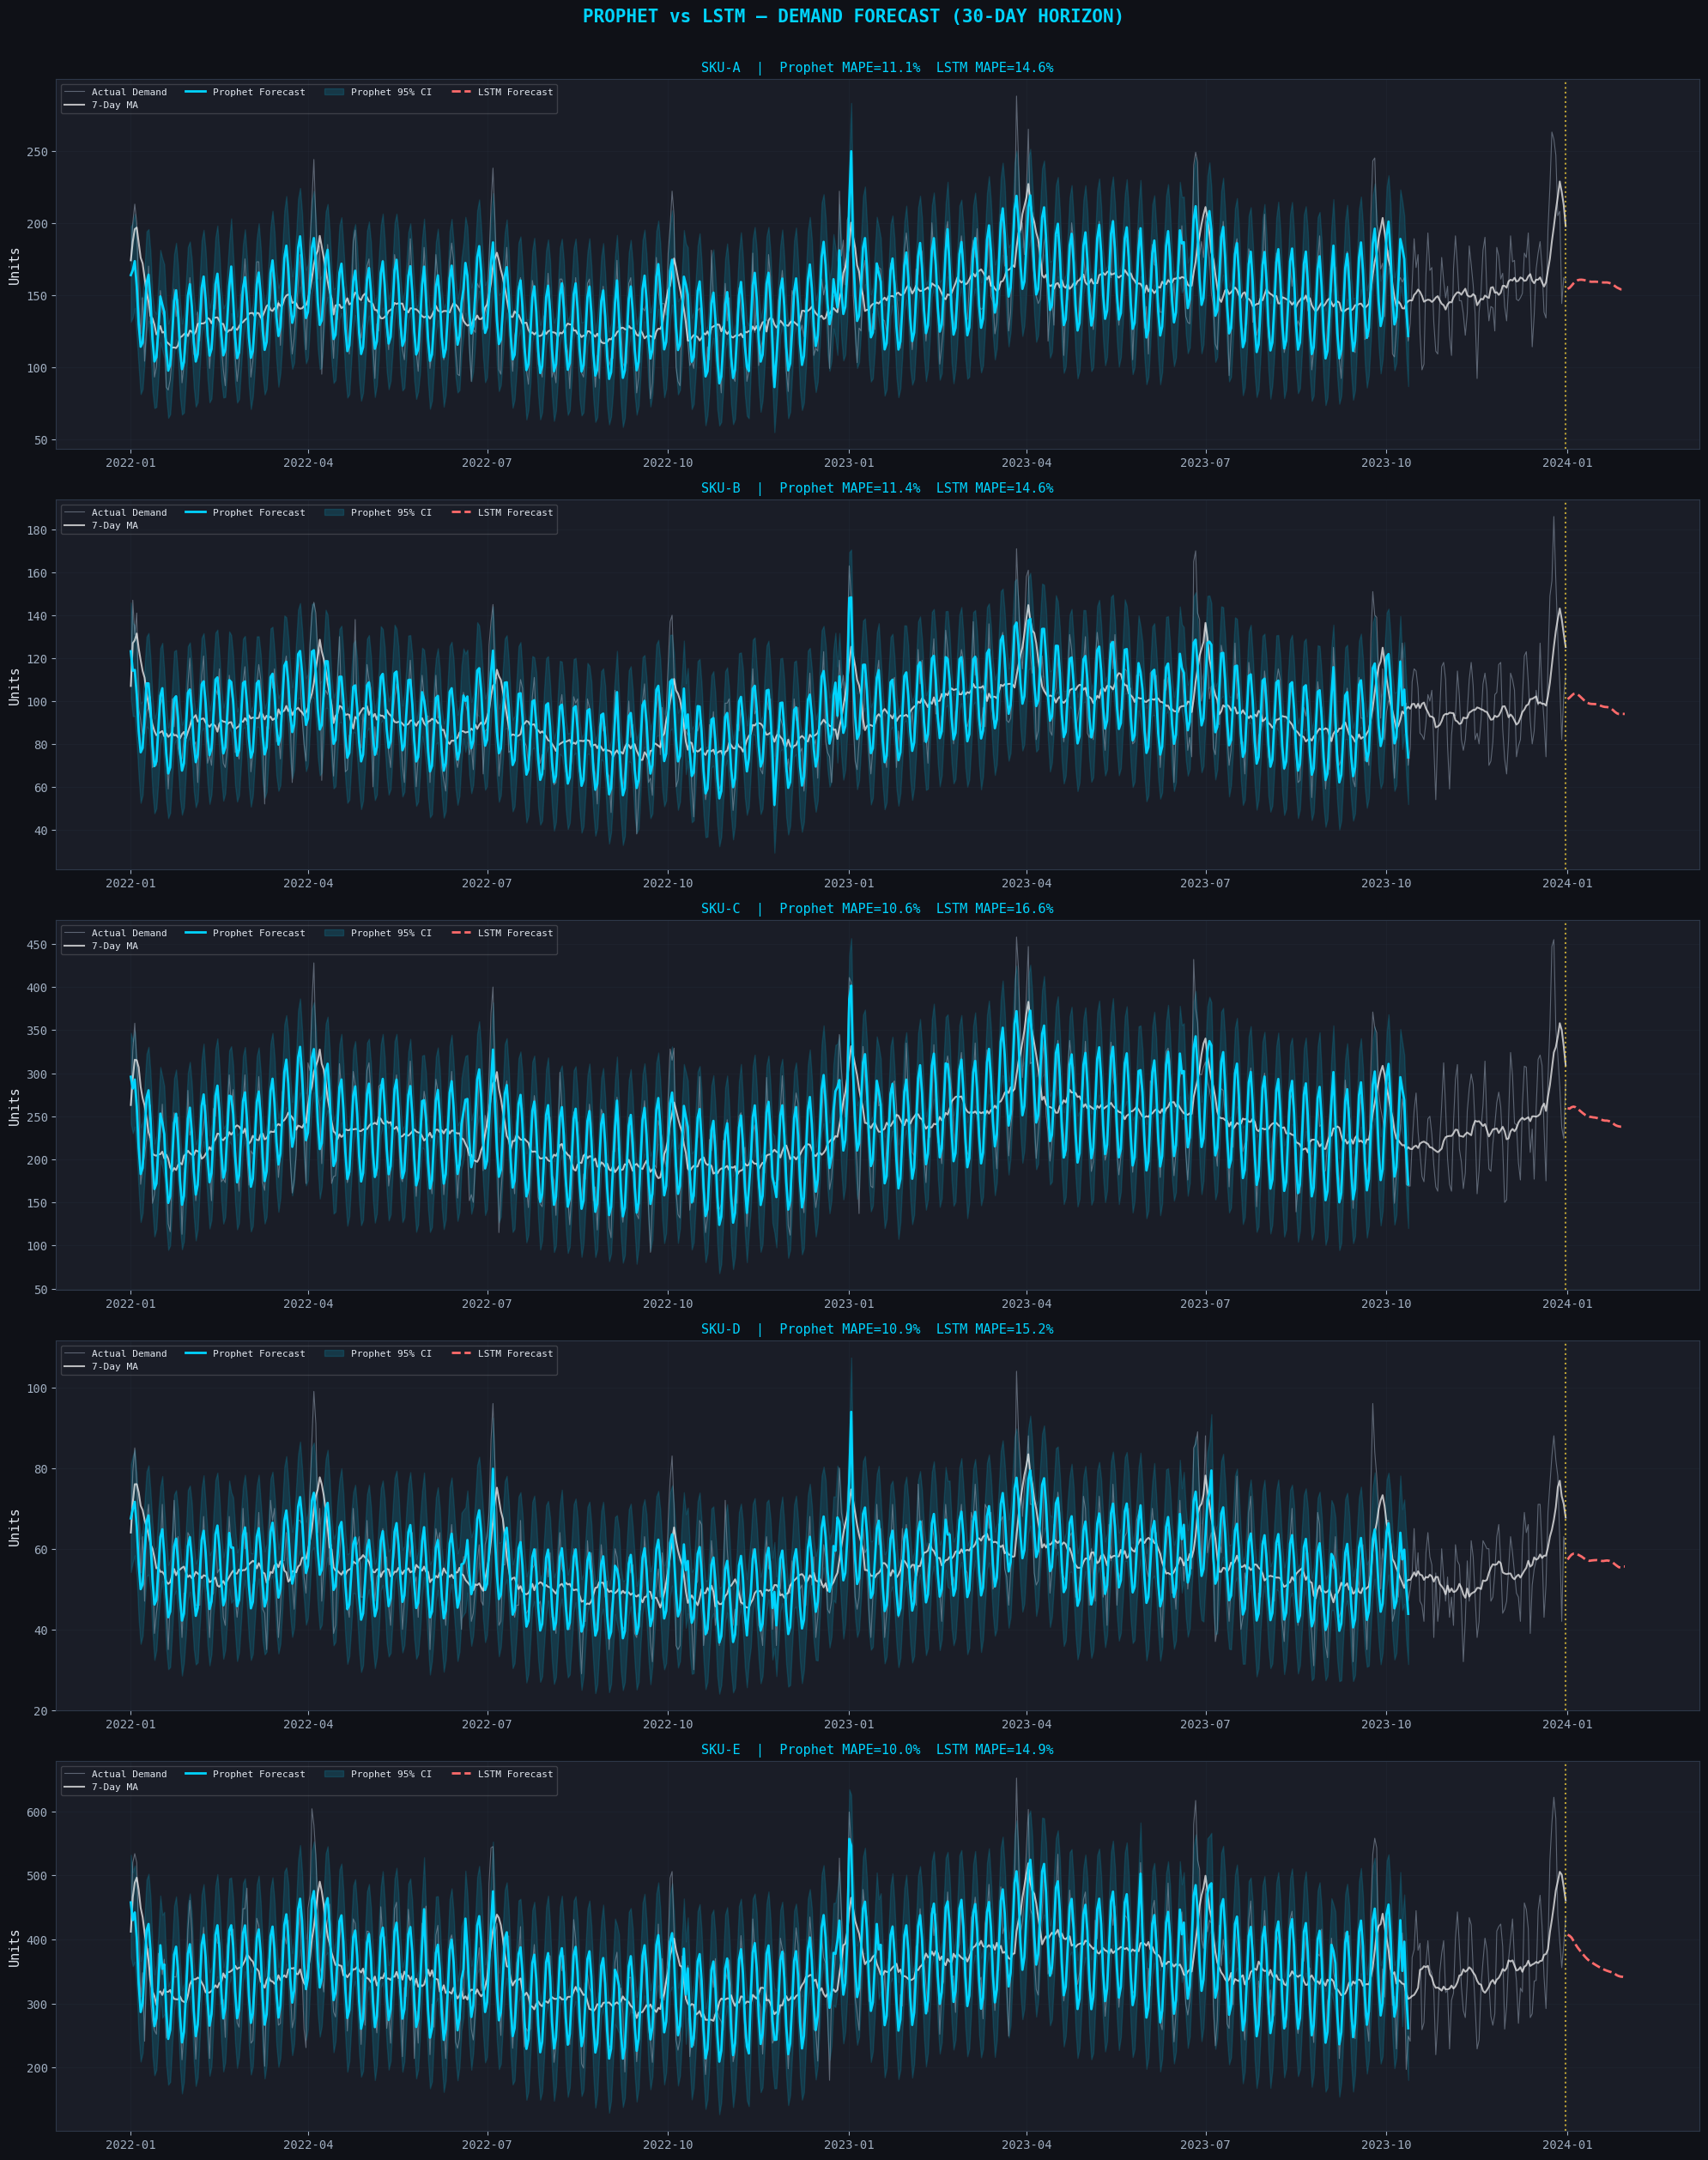

In [8]:
# ── Metrics table ─────────────────────────────────────────────────────────────
rows = []
for sku in df['sku'].unique():
    pm = results_prophet[sku]['metrics']
    lm = results_lstm[sku]['metrics']
    rows.append({'SKU': sku,
                 'Prophet MAE': pm['MAE'],  'Prophet RMSE': pm['RMSE'],  'Prophet MAPE%': pm['MAPE'],
                 'LSTM MAE':    lm['MAE'],  'LSTM RMSE':    lm['RMSE'],  'LSTM MAPE%':    lm['MAPE']})

metrics_df = pd.DataFrame(rows).set_index('SKU').round(2)
print('\n📊 Model Performance Comparison')
print('='*72)
print(metrics_df.to_string())
print('='*72)

# ── Forecast visualisation — Prophet vs LSTM ──────────────────────────────────
fig, axes = plt.subplots(len(df['sku'].unique()), 1,
                         figsize=(20, 5 * len(df['sku'].unique())), sharex=False)
fig.patch.set_facecolor('#0f1117')

for ax, sku in zip(axes, df['sku'].unique()):
    sub      = df[df['sku'] == sku].sort_values('date')
    pr_fc    = results_prophet[sku]['forecast']
    pr_dates = pd.to_datetime(pr_fc['ds'])
    fut_start= sub['date'].max() + timedelta(days=1)
    fut_dates= pd.date_range(fut_start, periods=FORECAST_HORIZON)
    lstm_fut = results_lstm[sku]['future_preds']

    # Actual
    ax.plot(sub['date'], sub['demand'], color='#a0aec0', lw=0.8, alpha=0.5, label='Actual Demand')
    ax.plot(sub['date'], sub['demand_7d_ma'], color='white', lw=1.5, alpha=0.7, label='7-Day MA')

    # Prophet forecast + CI
    ax.plot(pr_dates, pr_fc['yhat'], color=PALETTE[0], lw=2, label='Prophet Forecast')
    ax.fill_between(pr_dates, pr_fc['yhat_lower'], pr_fc['yhat_upper'],
                    alpha=0.15, color=PALETTE[0], label='Prophet 95% CI')

    # LSTM forecast
    ax.plot(fut_dates, lstm_fut, color=PALETTE[1], lw=2, ls='--', label='LSTM Forecast')

    ax.axvline(sub['date'].max(), color='#ffd93d', ls=':', lw=1.5, alpha=0.7)
    ax.set_title(f'{sku}  |  Prophet MAPE={results_prophet[sku]["metrics"]["MAPE"]:.1f}%  '
                 f'LSTM MAPE={results_lstm[sku]["metrics"]["MAPE"]:.1f}%',
                 color='#00d4ff', fontsize=11)
    ax.set_ylabel('Units'); ax.set_facecolor('#1a1d27')
    ax.legend(ncol=4, framealpha=0.2, fontsize=8)
    ax.grid(True, alpha=0.2)

plt.suptitle('PROPHET vs LSTM — DEMAND FORECAST (30-DAY HORIZON)',
             fontsize=15, color='#00d4ff', y=1.005, fontweight='bold')
plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


## 📦 Step 7 — Reorder Point & Safety Stock Computation

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Formulas:
#
#   Safety Stock  = Z × σ_demand × √(lead_time) + Z × avg_demand × σ_lt
#   Reorder Point = avg_demand × avg_lead_time + Safety Stock
#   EOQ           = √(2 × D × S / (H × C))
#   Avg Inventory = EOQ / 2 + Safety Stock
#   Annual Cost   = (D / EOQ) × S + (EOQ/2 + SS) × H × C
#
# ─────────────────────────────────────────────────────────────────────────────
Z_SCORE = 1.65   # 95% service level

inv_params = []

for sku in df['sku'].unique():
    sub = df[df['sku'] == sku]

    # ── Demand stats ──────────────────────────────────────────────────────────
    avg_d  = sub['demand'].mean()
    std_d  = sub['demand'].std()

    # ── Lead time stats ───────────────────────────────────────────────────────
    avg_lt = sub['lead_time_days'].mean()
    std_lt = sub['lead_time_days'].std()

    # ── Cost params ───────────────────────────────────────────────────────────
    unit_c = sub['unit_cost'].iloc[0]
    H_pct  = sub['holding_cost_pct'].iloc[0]
    S      = sub['order_cost'].iloc[0]
    D_ann  = avg_d * 365   # annual demand

    # ── Safety Stock (combined demand & lead-time variability) ─────────────────
    SS     = Z_SCORE * np.sqrt(avg_lt * std_d**2 + avg_d**2 * std_lt**2)

    # ── Reorder Point ─────────────────────────────────────────────────────────
    ROP    = avg_d * avg_lt + SS

    # ── EOQ ───────────────────────────────────────────────────────────────────
    H_cost = H_pct * unit_c
    EOQ    = np.sqrt((2 * D_ann * S) / H_cost)

    # ── Total annual cost ─────────────────────────────────────────────────────
    total_cost = (D_ann / EOQ) * S + (EOQ / 2 + SS) * H_cost
    avg_inv    = EOQ / 2 + SS

    # ── Use ensemble forecast for next-30d expected demand ────────────────────
    pr_30  = results_prophet[sku]['forecast'].tail(FORECAST_HORIZON)['yhat'].clip(lower=0).values
    ls_30  = results_lstm[sku]['future_preds']
    ens_30 = 0.55 * pr_30 + 0.45 * ls_30   # weighted ensemble

    inv_params.append({
        'SKU':            sku,
        'Avg Demand/day': round(avg_d, 1),
        'Std Demand':     round(std_d, 1),
        'Avg Lead Time':  round(avg_lt, 1),
        'Safety Stock':   round(SS, 0),
        'Reorder Point':  round(ROP, 0),
        'EOQ':            round(EOQ, 0),
        'Avg Inventory':  round(avg_inv, 0),
        'Annual Cost $':  round(total_cost, 0),
        'Unit Cost $':    unit_c,
        'Forecast 30d':   ens_30,
    })

inv_df = pd.DataFrame(inv_params).set_index('SKU')
display_cols = ['Avg Demand/day','Std Demand','Avg Lead Time','Safety Stock',
                'Reorder Point','EOQ','Avg Inventory','Annual Cost $']

print('\n📦 INVENTORY OPTIMIZATION PARAMETERS')
print('='*85)
print(inv_df[display_cols].to_string())
print('='*85)



📦 INVENTORY OPTIMIZATION PARAMETERS
       Avg Demand/day  Std Demand  Avg Lead Time  Safety Stock  Reorder Point     EOQ  Avg Inventory  Annual Cost $
SKU                                                                                                                
SKU-A           147.1        33.1            6.9         245.0         1265.0  1605.0         1047.0        11561.0
SKU-B            94.0        21.3            5.0         150.0          620.0   957.0          629.0        12455.0
SKU-C           236.6        59.1           10.0         438.0         2806.0  2628.0         1752.0        11498.0
SKU-D            55.6        11.3            3.0          83.0          249.0   552.0          359.0        12692.0
SKU-E           350.4        80.2           14.0         679.0         5589.0  4380.0         2869.0        10117.0


## 📈 Step 8 — Inventory Dashboard Visualisation

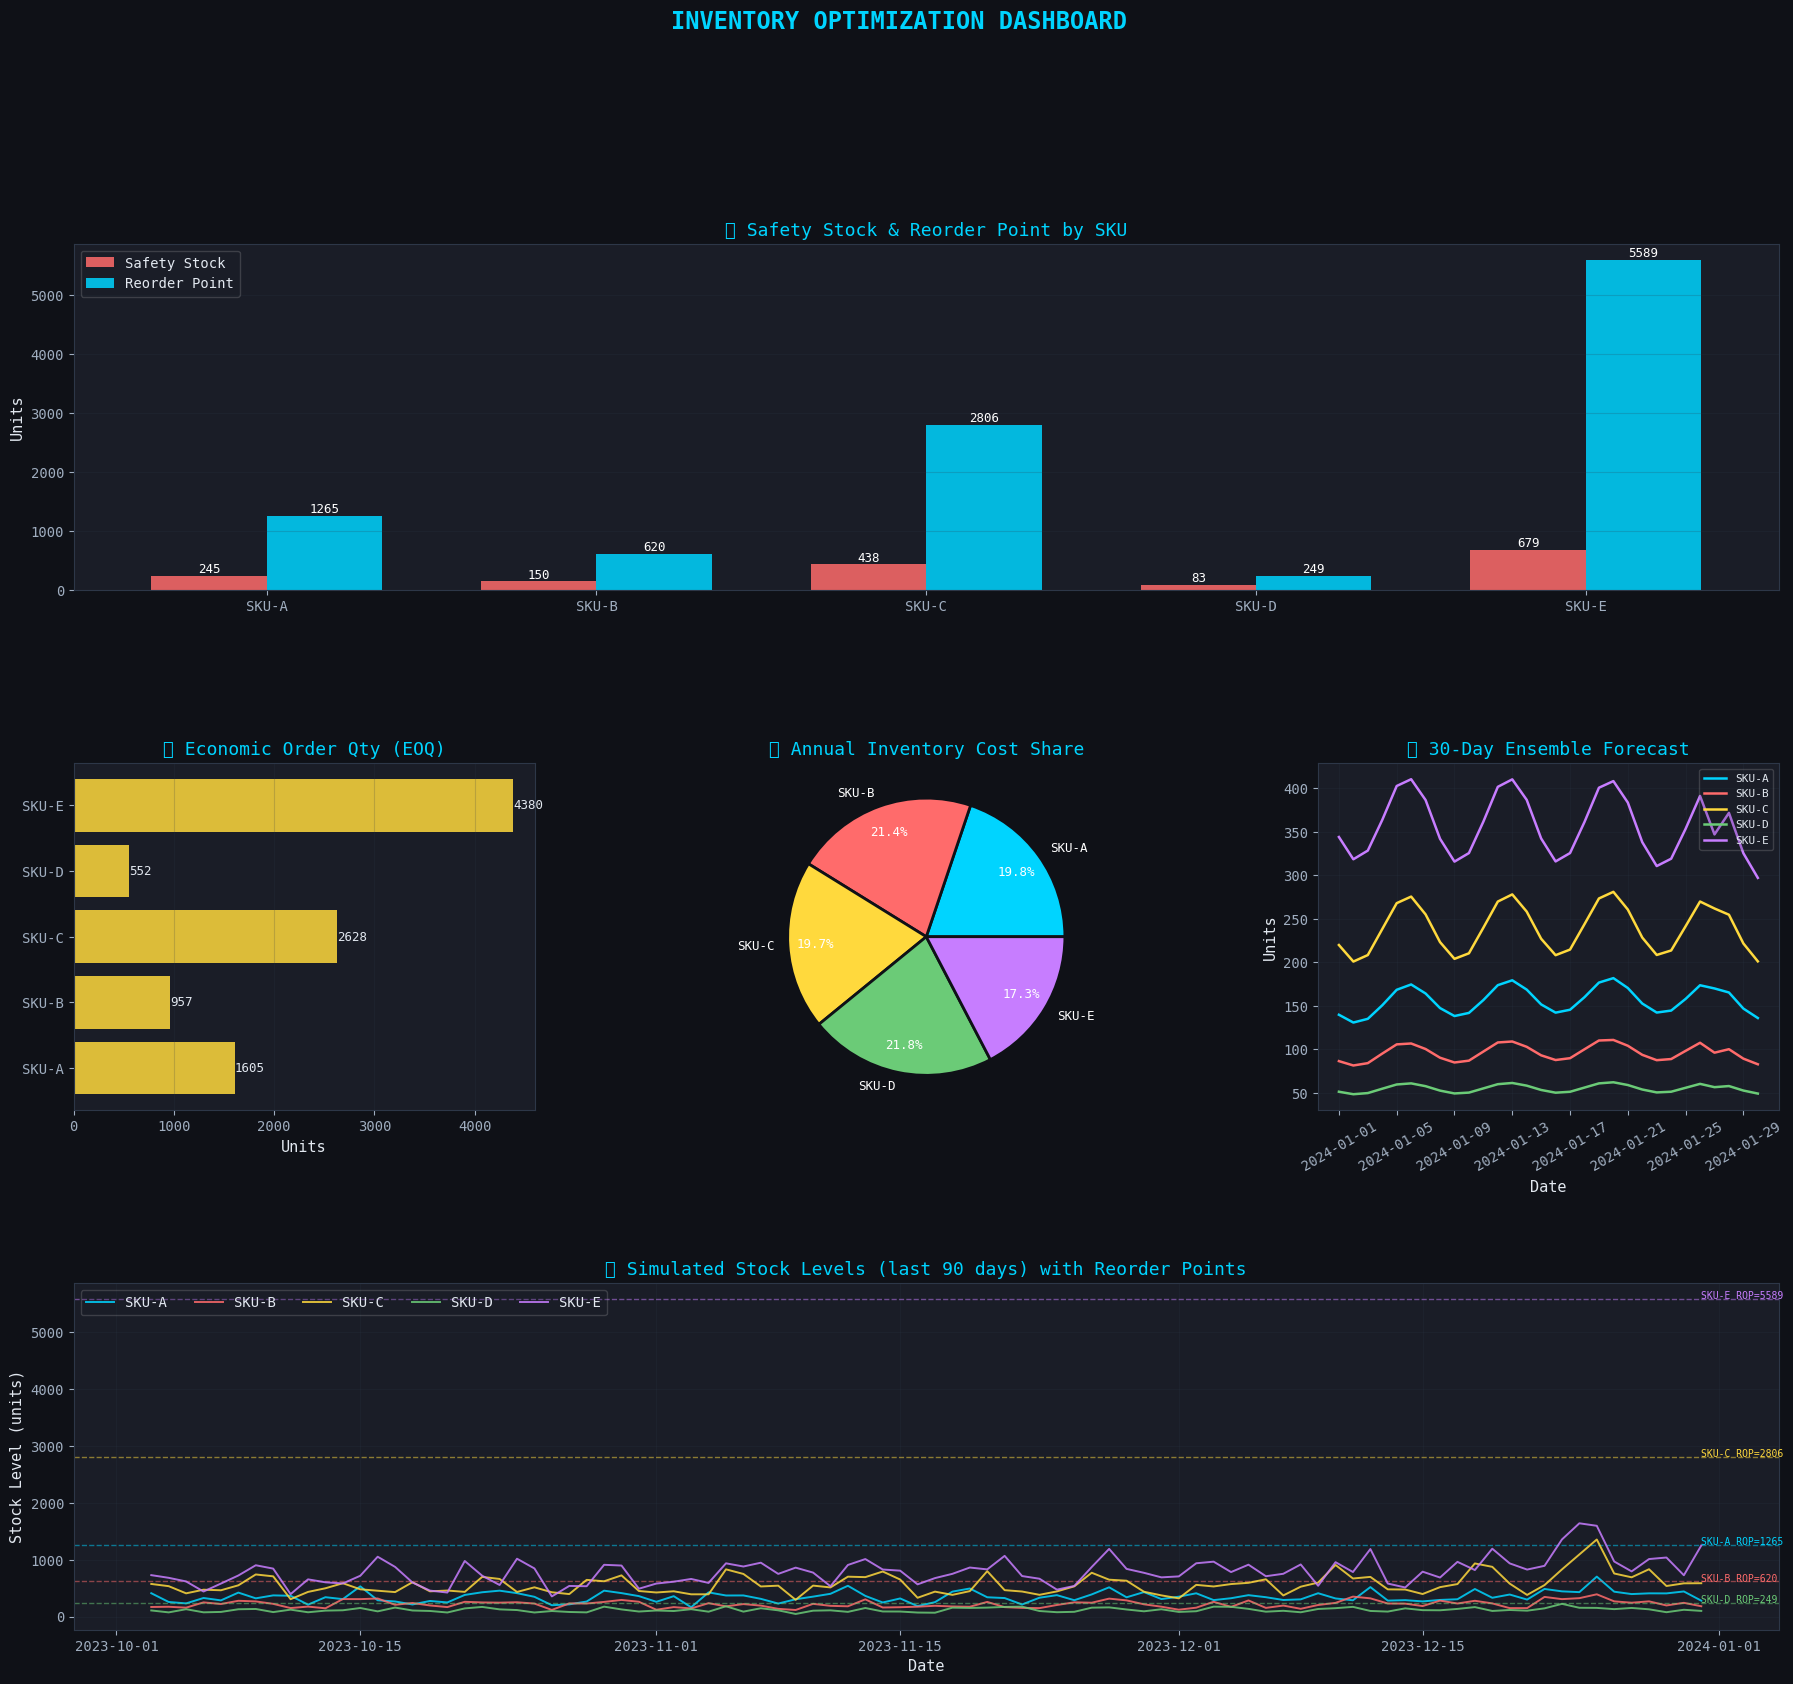

✅ Dashboard saved as inventory_dashboard.png


In [10]:
fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor('#0f1117')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

sku_labels = inv_df.index.tolist()

# ── Panel A: Safety Stock & ROP ────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, :])
x    = np.arange(len(sku_labels))
w    = 0.35
b1   = ax_a.bar(x - w/2, inv_df['Safety Stock'],  width=w, color=PALETTE[1], label='Safety Stock',  alpha=0.85)
b2   = ax_a.bar(x + w/2, inv_df['Reorder Point'], width=w, color=PALETTE[0], label='Reorder Point', alpha=0.85)
for bar in b1: ax_a.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f'{bar.get_height():.0f}',
                         ha='center', va='bottom', color='white', fontsize=9)
for bar in b2: ax_a.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f'{bar.get_height():.0f}',
                         ha='center', va='bottom', color='white', fontsize=9)
ax_a.set_xticks(x); ax_a.set_xticklabels(sku_labels)
ax_a.set_title('📦 Safety Stock & Reorder Point by SKU', color='#00d4ff')
ax_a.set_ylabel('Units'); ax_a.legend(framealpha=0.2); ax_a.grid(True, alpha=0.2, axis='y')
ax_a.set_facecolor('#1a1d27')

# ── Panel B: EOQ ──────────────────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[1, 0])
bars = ax_b.barh(sku_labels, inv_df['EOQ'], color=PALETTE[2], alpha=0.85)
for bar in bars: ax_b.text(bar.get_width()+3, bar.get_y()+bar.get_height()/2,
                            f'{bar.get_width():.0f}', va='center', fontsize=9)
ax_b.set_title('📐 Economic Order Qty (EOQ)', color='#00d4ff')
ax_b.set_xlabel('Units'); ax_b.set_facecolor('#1a1d27'); ax_b.grid(True, alpha=0.2, axis='x')

# ── Panel C: Annual Cost ───────────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 1])
ax_c.pie(inv_df['Annual Cost $'], labels=sku_labels, colors=PALETTE[:5],
         autopct='%1.1f%%', pctdistance=0.8,
         textprops={'color': 'white', 'fontsize': 9},
         wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2})
ax_c.set_title('💰 Annual Inventory Cost Share', color='#00d4ff')
ax_c.set_facecolor('#1a1d27')

# ── Panel D: 30-day Ensemble Forecast ─────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 2])
fut_dates = pd.date_range(df['date'].max() + timedelta(days=1), periods=FORECAST_HORIZON)
for sku, col in zip(sku_labels, PALETTE):
    fc = inv_df.loc[sku, 'Forecast 30d']
    ax_d.plot(fut_dates, fc, color=col, lw=1.8, label=sku)
ax_d.set_title('🔮 30-Day Ensemble Forecast', color='#00d4ff')
ax_d.set_ylabel('Units'); ax_d.set_xlabel('Date')
ax_d.legend(framealpha=0.2, fontsize=8)
ax_d.grid(True, alpha=0.2); ax_d.set_facecolor('#1a1d27')
ax_d.tick_params(axis='x', rotation=30)

# ── Panel E: Simulated Stock-Level with ROP lines ─────────────────────────────
ax_e = fig.add_subplot(gs[2, :])
for sku, col in zip(sku_labels, PALETTE):
    sub  = df[df['sku'] == sku].sort_values('date').tail(90)
    ax_e.plot(sub['date'], sub['stock_level'], color=col, lw=1.4, alpha=0.85, label=sku)
    rop  = inv_df.loc[sku, 'Reorder Point']
    ax_e.axhline(rop, color=col, ls='--', lw=1, alpha=0.5)
    ax_e.text(sub['date'].iloc[-1], rop + 2, f'{sku} ROP={rop:.0f}', color=col, fontsize=7)
ax_e.set_title('📉 Simulated Stock Levels (last 90 days) with Reorder Points', color='#00d4ff')
ax_e.set_ylabel('Stock Level (units)'); ax_e.set_xlabel('Date')
ax_e.legend(ncol=5, framealpha=0.2); ax_e.grid(True, alpha=0.2); ax_e.set_facecolor('#1a1d27')

plt.suptitle('INVENTORY OPTIMIZATION DASHBOARD', fontsize=17,
             color='#00d4ff', fontweight='bold', y=1.01)
plt.savefig('inventory_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('✅ Dashboard saved as inventory_dashboard.png')


## 💡 Step 9 — Business Insights & Recommendations

In [11]:
print('\n' + '='*80)
print('           💡 INVENTORY OPTIMIZATION — BUSINESS RECOMMENDATIONS')
print('='*80)

for sku in sku_labels:
    row    = inv_df.loc[sku]
    pm     = results_prophet[sku]['metrics']
    lm     = results_lstm[sku]['metrics']
    fc_30  = row['Forecast 30d']
    fc_sum = fc_30.sum()
    fc_avg = fc_30.mean()
    cv     = row['Std Demand'] / row['Avg Demand/day'] * 100

    # ── Risk classification ────────────────────────────────────────────────────
    risk   = 'HIGH ⚠️' if cv > 30 else ('MEDIUM 🟡' if cv > 15 else 'LOW ✅')

    # ── Best model ────────────────────────────────────────────────────────────
    best   = 'Prophet' if pm['MAPE'] < lm['MAPE'] else 'LSTM'
    b_mape = min(pm['MAPE'], lm['MAPE'])

    print(f'\n┌─── {sku} ────────────────────────────────────────────────────────┐')
    print(f'│ Demand Variability Risk : {risk} (CV = {cv:.1f}%)')
    print(f'│ Best Forecast Model     : {best} (MAPE = {b_mape:.1f}%)')
    print(f'│ Safety Stock            : {row["Safety Stock"]:.0f} units (95% SL, Z=1.65)')
    print(f'│ Reorder Point           : {row["Reorder Point"]:.0f} units')
    print(f'│ Economic Order Qty (EOQ): {row["EOQ"]:.0f} units / order')
    print(f'│ Est. Annual Inv. Cost   : ${row["Annual Cost $"]:,.0f}')
    print(f'│ 30-Day Forecast (sum)   : {fc_sum:.0f} units  (avg {fc_avg:.1f}/day)')
    print(f'│')
    print(f'│ 📋 ACTIONS:')

    # ── Action 1: Replenishment ────────────────────────────────────────────────
    print(f'│  1. Place an order of {row["EOQ"]:.0f} units when stock hits {row["Reorder Point"]:.0f} units.')

    # ── Action 2: Safety stock sensitivity ────────────────────────────────────
    if cv > 30:
        print(f'│  2. High demand volatility detected. Consider raising service level to 98% (Z=2.05).')
        print(f'│     Revised SS = {2.05 * np.sqrt(row["Avg Lead Time"] * row["Std Demand"]**2):.0f} units.')
    else:
        print(f'│  2. Demand is stable. Current safety stock provides adequate buffer.')

    # ── Action 3: Cost optimisation ────────────────────────────────────────────
    print(f'│  3. Holding cost = ${row["Unit Cost $"] * 0.25:.2f}/unit/yr. '
          f'Reducing avg inventory by 10% saves ${row["Annual Cost $"]*0.04:,.0f}/yr.')

    # ── Action 4: Forecast-driven pre-order ───────────────────────────────────
    print(f'│  4. Forecasted demand next 30 days = {fc_sum:.0f} units. '
          f'Pre-position stock before peak weeks.')

    print(f'└────────────────────────────────────────────────────────────────────┘')

print('\n' + '='*80)
print('  SYSTEM-LEVEL RECOMMENDATIONS')
print('='*80)
total_cost = inv_df['Annual Cost $'].sum()
print(f'  • Total portfolio annual inventory cost: ${total_cost:,.0f}')
print(f'  • SKU with highest reorder frequency   : {inv_df["EOQ"].idxmin()}')
print(f'  • SKU with highest annual cost         : {inv_df["Annual Cost $"].idxmax()}')
print(f'  • Potential savings (10% SS reduction) : ${total_cost * 0.04:,.0f}/year')
print(f'  • Recommended review cadence           : Daily for HIGH-risk SKUs, Weekly for LOW-risk')
print(f'  • Forecast model ensemble weights      : Prophet 55% + LSTM 45%')
print('='*80)
print('\n✅ Analysis complete. All outputs saved to current directory.')



           💡 INVENTORY OPTIMIZATION — BUSINESS RECOMMENDATIONS

┌─── SKU-A ────────────────────────────────────────────────────────┐
│ Demand Variability Risk : MEDIUM 🟡 (CV = 22.5%)
│ Best Forecast Model     : Prophet (MAPE = 11.1%)
│ Safety Stock            : 245 units (95% SL, Z=1.65)
│ Reorder Point           : 1265 units
│ Economic Order Qty (EOQ): 1605 units / order
│ Est. Annual Inv. Cost   : $11,561
│ 30-Day Forecast (sum)   : 4688 units  (avg 156.3/day)
│
│ 📋 ACTIONS:
│  1. Place an order of 1605 units when stock hits 1265 units.
│  2. Demand is stable. Current safety stock provides adequate buffer.
│  3. Holding cost = $6.25/unit/yr. Reducing avg inventory by 10% saves $462/yr.
│  4. Forecasted demand next 30 days = 4688 units. Pre-position stock before peak weeks.
└────────────────────────────────────────────────────────────────────┘

┌─── SKU-B ────────────────────────────────────────────────────────┐
│ Demand Variability Risk : MEDIUM 🟡 (CV = 22.7%)
│ Best Forecast Model 

## 💾 Step 10 — Export Results

In [12]:
# ── Export inventory parameters to CSV ───────────────────────────────────────
export_df = inv_df.drop(columns=['Forecast 30d']).copy()
for sku in sku_labels:
    fc = inv_df.loc[sku, 'Forecast 30d']
    export_df.loc[sku, 'Forecast_30d_sum']  = round(fc.sum(), 0)
    export_df.loc[sku, 'Forecast_30d_avg']  = round(fc.mean(), 2)
    export_df.loc[sku, 'Prophet_MAPE_%']    = round(results_prophet[sku]['metrics']['MAPE'], 2)
    export_df.loc[sku, 'LSTM_MAPE_%']       = round(results_lstm[sku]['metrics']['MAPE'], 2)

export_df.to_csv('inventory_optimization_results.csv')
print('✅ Results exported → inventory_optimization_results.csv')

# ── Verify saved files ────────────────────────────────────────────────────────
import os
files = ['eda_dashboard.png', 'decomposition.png', 'forecast_comparison.png',
         'inventory_dashboard.png', 'inventory_optimization_results.csv']
print('\n📁 Output files:')
for f in files:
    size = os.path.getsize(f) / 1024 if os.path.exists(f) else 0
    status = f'✅ {size:.1f} KB' if size > 0 else '❌ missing'
    print(f'   {f:<45} {status}')


✅ Results exported → inventory_optimization_results.csv

📁 Output files:
   eda_dashboard.png                             ✅ 481.5 KB
   decomposition.png                             ✅ 725.3 KB
   forecast_comparison.png                       ✅ 3040.1 KB
   inventory_dashboard.png                       ✅ 423.9 KB
   inventory_optimization_results.csv            ✅ 0.6 KB
